Batches:   0%|          | 0/329 [00:00<?, ?it/s]

✅ PCA applied. Retained Variance: 0.7483

📊 Silhouette Score (Full Data): 0.0754


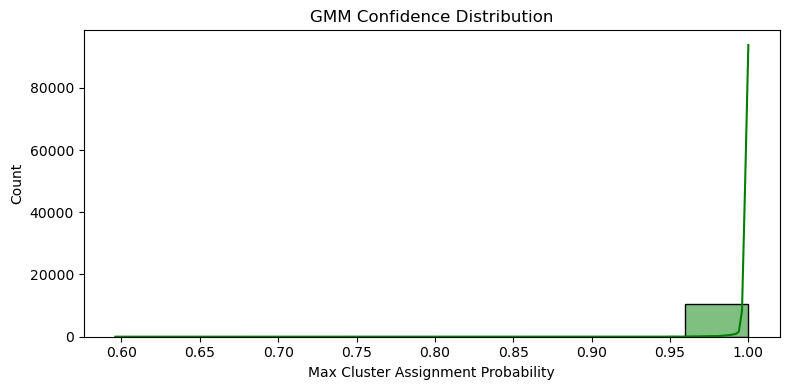

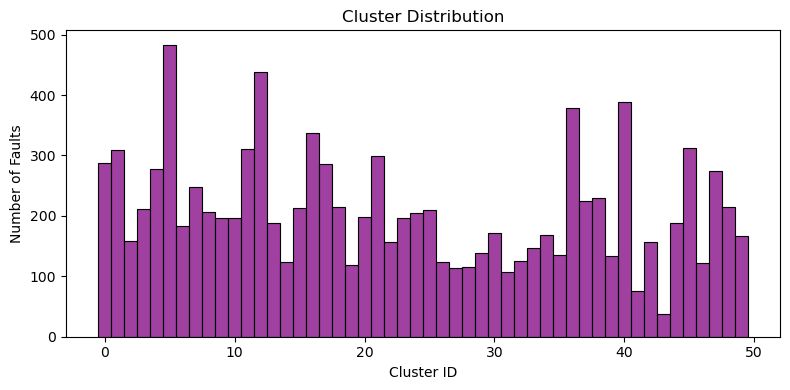

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# 1. Load the dataset
input_file = "GMM-train-RAG.xlsx"
df = pd.read_excel(input_file)

# 2. Ensure required column exists
assert "Fault Description" in df.columns, "Missing 'Fault Description' column"

# 3. Extract fault descriptions
fault_descriptions = df["Fault Description"].astype(str).tolist()

# 4. Generate MiniLM sentence embeddings
model = SentenceTransformer("paraphrase-MiniLM-L6-v2")
embeddings = model.encode(fault_descriptions, show_progress_bar=True)

# 5. Normalize embeddings
embeddings = normalize(embeddings)

# 6. Apply PCA (increase dimensions for better variance capture)
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(embeddings)

explained = np.sum(pca.explained_variance_ratio_)
print(f"✅ PCA applied. Retained Variance: {explained:.4f}")

# 7. Train Gaussian Mixture Model
K = 50  # Number of clusters
gmm = GaussianMixture(
    n_components=K,
    covariance_type="full",
    max_iter=2000,
    n_init=20,
    random_state=42
)
gmm.fit(X_pca)

# 8. Predict clusters and probabilities
clusters = gmm.predict(X_pca)
probs = gmm.predict_proba(X_pca)
max_probs = np.max(probs, axis=1)

# 9. Create DataFrame with results
result_df = pd.DataFrame({
    "Fault Description": fault_descriptions,
    "Cluster": clusters,
    "Max Probability": max_probs
})

# 10. Save models and results
os.makedirs("saved_models", exist_ok=True)
joblib.dump(pca, "saved_models/pca_model.joblib")
joblib.dump(gmm, "saved_models/gmm_model.joblib")
result_df.to_csv("saved_models/gmm_clustered_full.csv", index=False)

# 11. Compute and display silhouette score
sil_score = silhouette_score(X_pca, clusters)
print(f"\n📊 Silhouette Score (Full Data): {sil_score:.4f}")

# 12. Plot: Probability distribution
plt.figure(figsize=(8, 4))
sns.histplot(result_df["Max Probability"], bins=10, kde=True, color="green")
plt.xlabel("Max Cluster Assignment Probability")
plt.ylabel("Count")
plt.title("GMM Confidence Distribution")
plt.tight_layout()
plt.show()

# 13. Plot: Cluster distribution
plt.figure(figsize=(8, 4))
sns.histplot(result_df["Cluster"], bins=K, discrete=True, color="purple")
plt.xlabel("Cluster ID")
plt.ylabel("Number of Faults")
plt.title("Cluster Distribution")
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from sentence_transformers import SentenceTransformer, util

# Load data
reference_df = pd.read_excel("clusters_reference.xlsx")
unlabeled_df = pd.read_excel("to_be_labeled.xlsx")

# Extract text
ref_texts = reference_df["Fault Description"].astype(str).tolist()
ref_clusters = reference_df["Cluster"].tolist()
unlabeled_texts = unlabeled_df["Fault Description"].astype(str).tolist()

# Load model
model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")

ref_embeddings = model.encode(ref_texts, convert_to_tensor=True, normalize_embeddings=True)
unlabeled_embeddings = model.encode(unlabeled_texts, convert_to_tensor=True, normalize_embeddings=True)

# Match and assign clusters
assigned_clusters = []
similarity_scores = []

for emb in unlabeled_embeddings:
    cosine_scores = util.cos_sim(emb, ref_embeddings)[0]
    top_idx = cosine_scores.argmax().item()
    assigned_clusters.append(ref_clusters[top_idx])
    similarity_scores.append(float(cosine_scores[top_idx]))

# Save results
unlabeled_df["Expected Cluster"] = assigned_clusters
unlabeled_df["Similarity Score"] = similarity_scores
unlabeled_df.to_excel("labeled_faults_with_similarity.xlsx", index=False)

print("✅ Done! Saved to labeled_faults_with_similarity.xlsx")


✅ Done! Saved to labeled_faults_with_similarity.xlsx



📊 Evaluation Metrics:
Accuracy : 0.9371
Precision: 0.9158
Recall   : 0.9097
F1 Score : 0.9089

🔍 Inference Results:
                                      Fault Description Expected Cluster  \
0      is not available. [ 0 ] could not assign _ rr...               10   
1     .o.d.u.i.c.RequestInterfaceSetup() /home/oran/...                8   
2      ( 1 ; 31m [ nr _ rrc ] [ dl ] ( cellid bc614e...               49   
3     .exe /home / oran / openairinterface5g / opena...               11   
4      ausdallas-nas-amfd[13098]: 02/13/2015 sgcpcd[...               42   
...                                                 ...              ...   
1045  1 = ‘ 0 & – 1; #[ 0m #[ 0m #[ 0m #[ rrc ] unkn...                7   
1046   12h 44m [ ngap ] [ ngap ] [ dl ] check the am...               28   
1047  1 rrc /home / oran / openairinterface5g / nrf ...               36   
1048  g | grep - rval | sctp | gnb. sa. band78. fr1....               17   
1049   13 22 : 54 : 59 srs - ran open5gs - pcfd

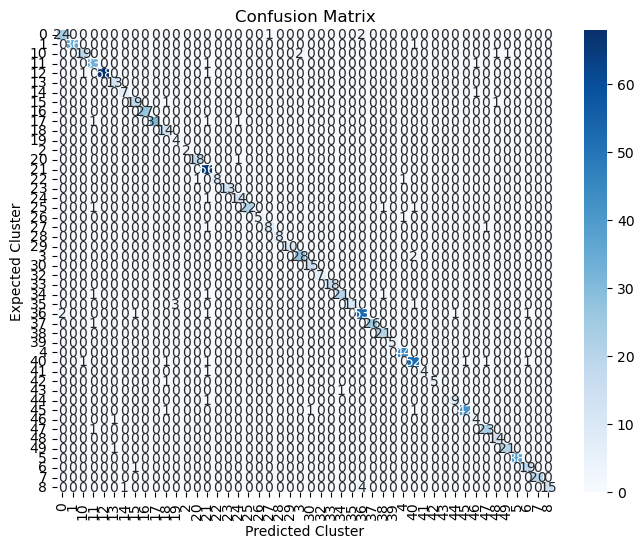


💾 Results saved to 'gmm_inference_evaluation.csv'


In [2]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize, LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load previously saved models
pca = joblib.load("saved_models/pca_model.joblib")
gmm = joblib.load("saved_models/gmm_model.joblib")


# ---- STEP 1: Load the inference Excel file ----
inference_file = "gmm-inference.xlsx"  # <-- change to your filename if needed
inference_df = pd.read_excel(inference_file)

# Validate required columns
if not {"Fault Description", "Expected Cluster"}.issubset(inference_df.columns):
    raise ValueError("Excel must contain both 'Fault Description' and 'Expected Cluster' columns.")

new_faults = inference_df["Fault Description"].astype(str).tolist()
true_labels = inference_df["Expected Cluster"].astype(str).tolist()  # Keep as string in case they're names

# ---- STEP 2: Reuse Trained Models (assumes GMM, PCA, and embedding model are already loaded) ----
model = SentenceTransformer('paraphrase-MiniLM-L6-v2')  # Reuse or reload the same model
new_embeddings = model.encode(new_faults)

# Normalize
norms = np.linalg.norm(new_embeddings, axis=1)
if not np.allclose(norms, 1, atol=1e-3):
    new_embeddings = normalize(new_embeddings, axis=1)

# Transform using trained PCA
new_pca = pca.transform(new_embeddings)

# Predict using trained GMM
predicted_clusters = gmm.predict(new_pca)
predicted_probs = gmm.predict_proba(new_pca)
max_probs = np.max(predicted_probs, axis=1)

# Encode both true and predicted labels correctly
true_labels_str = [str(label) for label in true_labels]
predicted_labels_str = [str(label) for label in predicted_clusters]

label_encoder = LabelEncoder()
label_encoder.fit(true_labels_str + predicted_labels_str)

true_encoded = label_encoder.transform(true_labels_str)
pred_encoded = label_encoder.transform(predicted_labels_str)

# Calculate scores
accuracy = accuracy_score(true_encoded, pred_encoded)
precision = precision_score(true_encoded, pred_encoded, average='macro', zero_division=0)
recall = recall_score(true_encoded, pred_encoded, average='macro', zero_division=0)
f1 = f1_score(true_encoded, pred_encoded, average='macro', zero_division=0)

print("\n📊 Evaluation Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


# ---- STEP 5: Show Results ----
results_df = pd.DataFrame({
    "Fault Description": new_faults,
    "Expected Cluster": true_labels,
    "Predicted Cluster": predicted_clusters,
    "Confidence (Max Prob)": max_probs
})
print("\n🔍 Inference Results:")
print(results_df)

# ---- STEP 6: Confusion Matrix ----
cm = confusion_matrix(true_encoded, pred_encoded, labels=np.unique(true_encoded))
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Cluster")
plt.ylabel("Expected Cluster")
plt.title("Confusion Matrix")
plt.show()

# ---- STEP 7: Optional – Save results ----
results_df.to_csv("gmm_inference_evaluation.csv", index=False)
print("\n💾 Results saved to 'gmm_inference_evaluation.csv'")


In [15]:
import openai
import pandas as pd
from sentence_transformers import SentenceTransformer, util
import numpy as np
import time


In [16]:
inference_df = pd.read_excel("gmm_inference_evaluation.xlsx")
kb_df = pd.read_excel("final_merged_resolutions_10500.xlsx")


In [17]:
model = SentenceTransformer("sentence-transformers/paraphrase-MiniLM-L6-v2")

# Precompute embeddings for KB
kb_df["Fault Description"] = kb_df["Fault Description"].astype(str)
kb_embeddings = model.encode(kb_df["Fault Description"].tolist(), convert_to_tensor=True)

In [18]:
openai.api_key = "API_KEY"


In [19]:
import torch
results = []

for idx, row in inference_df.iterrows():
    fault = row["Fault Description"]
    cluster = row["Predicted Cluster"]

    # Filter KB by matching cluster
    cluster_kb = kb_df[kb_df["Cluster"] == cluster].reset_index(drop=True)
    if cluster_kb.empty:
        results.append(["[No cluster match]"] * 5)
        continue

    # Compute similarity
    fault_embedding = model.encode(fault, convert_to_tensor=True)
    cluster_embeddings = model.encode(cluster_kb["Fault Description"].tolist(), convert_to_tensor=True)
    cos_scores = util.cos_sim(fault_embedding, cluster_embeddings)[0]
    top_indices = torch.topk(cos_scores, k=min(2, len(cluster_kb))).indices.tolist()

    # Few-shot prompt with improved instruction
    prompt = (
        "You are an expert network engineer. Based on the following examples, generate a clear, specific, and actionable resolution for the last fault.\n"
        "Do not include the word 'Resolution:' in your answer. Keep your response concise and within 3–4 lines.\n\n"
    )
    for i in top_indices:
        example_fault = cluster_kb.iloc[i]["Fault Description"]
        example_resolution = cluster_kb.iloc[i]["Resolution"]
        prompt += f"Fault: {example_fault}\nResolution: {example_resolution}\n\n"

    prompt += f"Fault: {fault}\n"

    fault_resolutions = []
    for _ in range(5):
        try:
            response = openai.ChatCompletion.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.5,
                max_tokens=200
            )
            output = response["choices"][0]["message"]["content"].strip()

            # Strip leading "Resolution:" if GPT still returns it
            if output.lower().startswith("resolution:"):
                output = output[len("resolution:"):].strip()

            fault_resolutions.append(output)

        except Exception as e:
            fault_resolutions.append(f"[Error: {str(e)}]")

        time.sleep(1.2)

    results.append(fault_resolutions)


In [20]:
resolution_df = pd.DataFrame(results, columns=[f"Resolution {i+1}" for i in range(5)])
final_df = pd.concat([inference_df, resolution_df], axis=1)
final_df.to_excel("gmm_enhanced_with_gpt_resolutions.xlsx", index=False)
print("✅ Saved to gmm_enhanced_with_gpt_resolutions.xlsx")


✅ Saved to gmm_enhanced_with_gpt_resolutions.xlsx


In [22]:
import openai
import pandas as pd
import time
from tqdm import tqdm  # For progress bar

# Set your OpenAI API key
openai.api_key = "API_KEY"

# Load fault descriptions
df = pd.read_excel("gmm_inference_evaluation.xlsx")
faults = df["Fault Description"].astype(str).tolist()

# Store 5 responses per fault
all_resolutions = []

for idx, fault in enumerate(tqdm(faults, desc="Generating Resolutions"), start=1):
    prompt = fault  # just the fault, no extra instructions

    try:
        response = openai.ChatCompletion.create(
            model="gpt-4o",
            messages=[{"role": "user", "content": prompt}],
            temperature=0.7,
            max_tokens=100,
            n=5  # Request 5 completions
        )
        resolutions = [choice["message"]["content"].strip() for choice in response["choices"]]
    except Exception as e:
        resolutions = [f"[Error: {str(e)}]"] * 5

    print(f"✅ Row {idx}: {resolutions[0][:80]}...")
    all_resolutions.append(resolutions)
    time.sleep(1.2)

# Append to dataframe
for i in range(5):
    df[f"ZeroShot Resolution {i+1}"] = [r[i] for r in all_resolutions]

# Save to Excel
df.to_excel("gmm_zero_shot_minimal_prompt.xlsx", index=False)
print("✅ File saved: gmm_zero_shot_minimal_prompt.xlsx")


Generating Resolutions:   0%|                          | 0/1050 [00:00<?, ?it/s]

✅ Row 1: The message you provided seems to be a combination of error logs or messages rel...


Generating Resolutions:   0%|                | 1/1050 [00:04<1:21:39,  4.67s/it]

✅ Row 2: It seems you're encountering an error related to configuration file paths or par...


Generating Resolutions:   0%|                | 2/1050 [00:09<1:19:46,  4.57s/it]

...

✅ Row 1049: The error message you're encountering suggests there are issues with the configu...


Generating Resolutions: 100%|████████████▉| 1049/1050 [1:24:42<00:04,  4.72s/it]

✅ Row 1050: This log entry indicates a warning from a software component, likely part of an ...


Generating Resolutions: 100%|█████████████| 1050/1050 [1:24:46<00:00,  4.84s/it]

✅ File saved: gmm_zero_shot_minimal_prompt.xlsx


In [3]:
import pandas as pd
import numpy as np
import time
import torch
import joblib
import openai

from sentence_transformers import SentenceTransformer, util
from sklearn.preprocessing import normalize

# --- Load pretrained models ---
pca = joblib.load("saved_models/pca_model.joblib")
gmm = joblib.load("saved_models/gmm_model.joblib")
embed_model = SentenceTransformer("paraphrase-MiniLM-L6-v2")

# --- Load data ---
inference_df = pd.read_excel("gmm-inference.xlsx")
kb_df = pd.read_excel("final_merged_resolutions_10500.xlsx")
kb_df["Fault Description"] = kb_df["Fault Description"].astype(str)

# --- Precompute KB embeddings ---
kb_embeddings = embed_model.encode(kb_df["Fault Description"].tolist(), convert_to_tensor=True)

# --- Prepare output containers ---
resolutions_all = []
timings_all = []
clusters_all = []

openai.api_key = "API_KEY"  # Replace with your actual key

# --- Process each fault record ---
for idx, row in inference_df.iterrows():
    fault = str(row["Fault Description"])

    # --- Start time: from predicting cluster ---
    start_time = time.time()

    # Step 1: Encode and normalize embedding
    fault_embed = embed_model.encode([fault], convert_to_tensor=False)
    fault_embed = normalize(fault_embed)[0]

    # Step 2: Apply PCA and predict cluster
    fault_pca = pca.transform([fault_embed])
    predicted_cluster = gmm.predict(fault_pca)[0]
    clusters_all.append(predicted_cluster)

    # Step 3: Filter KB records by cluster
    cluster_kb = kb_df[kb_df["Cluster"] == predicted_cluster].reset_index(drop=True)
    if cluster_kb.empty:
        resolutions_all.append(["[No matching cluster]"] * 5)
        timings_all.append([0.0] * 5)
        continue

    # Step 4: Get embeddings for filtered KB
    cluster_texts = cluster_kb["Fault Description"].tolist()
    cluster_embeddings = embed_model.encode(cluster_texts, convert_to_tensor=True)

    # Step 5: Cosine similarity and top-2 selection
    device = cluster_embeddings.device
    fault_embed_tensor = torch.tensor(fault_embed, device=device).unsqueeze(0)
    cos_scores = util.cos_sim(fault_embed_tensor, cluster_embeddings)[0]
    top_indices = torch.topk(cos_scores, k=min(2, len(cluster_kb))).indices.tolist()

    # Step 6: Construct prompt
    prompt = (
        "You are an expert network engineer. Based on the following examples, generate a clear, specific, and actionable resolution for the last fault.\n"
        "Do not include the word 'Resolution:' in your answer. Keep your response concise and within 3–4 lines.\n\n"
    )
    for i in top_indices:
        ex_fault = cluster_kb.iloc[i]["Fault Description"]
        ex_res = cluster_kb.iloc[i]["Resolution"]
        prompt += f"Fault: {ex_fault}\nResolution: {ex_res}\n\n"
    prompt += f"Fault: {fault}\n"

    # Step 7: Generate 5 resolutions
    fault_resolutions = []
    run_times = []

    for _ in range(5):
        run_start = time.time()
        try:
            response = openai.ChatCompletion.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.5,
                max_tokens=200,
            )
            output = response["choices"][0]["message"]["content"].strip()
            if output.lower().startswith("resolution:"):
                output = output[len("resolution:"):].strip()
        except Exception as e:
            output = f"[Error: {str(e)}]"
        run_end = time.time()

        fault_resolutions.append(output)
        run_times.append(round(run_end - run_start, 2))
        time.sleep(1.2)  # to respect rate limits

    resolutions_all.append(fault_resolutions)
    timings_all.append(run_times)

# --- Final Output ---
res_df = pd.DataFrame(resolutions_all, columns=[f"Resolution {i+1}" for i in range(5)])
time_df = pd.DataFrame(timings_all, columns=[f"Time {i+1} (s)" for i in range(5)])
time_df["Mean Time (s)"] = time_df.mean(axis=1).round(2)
time_df["Std Time (s)"] = time_df.std(axis=1).round(2)

final_df = pd.DataFrame({
    "Fault Description": inference_df["Fault Description"],
    "Predicted Cluster": clusters_all
})

final_df = pd.concat([final_df, res_df, time_df], axis=1)
final_df.to_excel("gmm_inference_resolutions_timed.xlsx", index=False)
print("✅ Output saved to gmm_inference_resolutions_timed.xlsx")


✅ Output saved to gmm_inference_resolutions_timed.xlsx


In [4]:
import pandas as pd
import numpy as np
import torch
import time
from sentence_transformers import SentenceTransformer, util
import openai
from tqdm import tqdm

# Load inference fault records
inference_df = pd.read_excel("gmm-inference.xlsx")
inference_df["Fault Description"] = inference_df["Fault Description"].astype(str)

# Load knowledge base
kb_df = pd.read_excel("final_merged_resolutions_10500.xlsx")
kb_df["Fault Description"] = kb_df["Fault Description"].astype(str)

# Load MiniLM model and precompute KB embeddings
model = SentenceTransformer("sentence-transformers/paraphrase-MiniLM-L6-v2")
kb_embeddings = model.encode(kb_df["Fault Description"].tolist(), convert_to_tensor=True)

# Set OpenAI API key
openai.api_key = "API_KEY"  # Replace with your actual key

# Results storage
all_results = []

# Process each fault in inference set
for idx, row in tqdm(inference_df.iterrows(), total=len(inference_df)):
    fault = row["Fault Description"]
    fault_embed = model.encode(fault)
    fault_embed_tensor = torch.tensor(fault_embed, device=kb_embeddings.device).unsqueeze(0)

    run_times = []
    fault_resolutions = []

    for _ in range(5):
        try:
            start = time.time()

            # Compute cosine similarity with all KB embeddings
            cos_scores = util.cos_sim(fault_embed_tensor, kb_embeddings)[0]
            top_indices = torch.topk(cos_scores, k=2).indices.tolist()

            # Build the prompt
            prompt = (
                "You are an expert network engineer. Based on the following examples, generate a clear, specific, and actionable resolution for the last fault.\n"
                "Do not include the word 'Resolution:' in your answer. Keep your response concise and within 3–4 lines.\n\n"
            )
            for i in top_indices:
                ex_fault = kb_df.iloc[i]["Fault Description"]
                ex_res = kb_df.iloc[i]["Resolution"]
                prompt += f"Fault: {ex_fault}\nResolution: {ex_res}\n\n"

            prompt += f"Fault: {fault}\n"

            # OpenAI call
            response = openai.ChatCompletion.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.5,
                max_tokens=200
            )
            output = response["choices"][0]["message"]["content"].strip()
            if output.lower().startswith("resolution:"):
                output = output[len("resolution:"):].strip()

            end = time.time()
            run_times.append(end - start)
            fault_resolutions.append(output)

        except Exception as e:
            run_times.append(0.0)
            fault_resolutions.append(f"[Error: {str(e)}]")

        time.sleep(1.2)

    # Store result
    result_row = {
        "Fault Description": fault,
        "Resolution 1": fault_resolutions[0],
        "Resolution 2": fault_resolutions[1],
        "Resolution 3": fault_resolutions[2],
        "Resolution 4": fault_resolutions[3],
        "Resolution 5": fault_resolutions[4],
        "Time 1": run_times[0],
        "Time 2": run_times[1],
        "Time 3": run_times[2],
        "Time 4": run_times[3],
        "Time 5": run_times[4],
        "Time Mean": np.mean(run_times),
        "Time Std": np.std(run_times)
    }
    all_results.append(result_row)

# Save final results
final_df = pd.DataFrame(all_results)
final_df.to_excel("no_cluster_gpt_results.xlsx", index=False)


100%|█████████████████████████████████████████████| 1/1 [00:17<00:00, 17.69s/it]


In [7]:
import pandas as pd
import numpy as np
import torch
import time
from sentence_transformers import SentenceTransformer, util
import openai
from tqdm import tqdm

# Load inference fault records
inference_df = pd.read_excel("gmm-inference.xlsx")
inference_df["Fault Description"] = inference_df["Fault Description"].astype(str)

# Load knowledge base
kb_df = pd.read_excel("final_merged_resolutions_10500.xlsx")
kb_df["Fault Description"] = kb_df["Fault Description"].astype(str)

# Load MiniLM model and precompute KB embeddings
model = SentenceTransformer("sentence-transformers/paraphrase-MiniLM-L6-v2")
kb_embeddings = model.encode(kb_df["Fault Description"].tolist(), convert_to_tensor=True)

# Set OpenAI API key

client = OpenAI(api_key="API_KEY")
# Results storage
all_results = []

# Process each fault in inference set
for idx, row in tqdm(inference_df.iterrows(), total=len(inference_df)):
    fault = row["Fault Description"]
    run_times = []
    fault_resolutions = []

    for _ in range(5):
        try:
            start = time.time()

            # Re-encode the fault in each run to simulate independent runs
            fault_embed = model.encode(fault)
            fault_embed_tensor = torch.tensor(fault_embed, device=kb_embeddings.device).unsqueeze(0)

            # Compute cosine similarity with all KB embeddings
            cos_scores = util.cos_sim(fault_embed_tensor, kb_embeddings)[0]
            top_indices = torch.topk(cos_scores, k=2).indices.tolist()

            # Build the prompt
            prompt = (
                "You are an expert network engineer. Based on the following examples, generate a clear, specific, and actionable resolution for the last fault.\n"
                "Do not include the word 'Resolution:' in your answer. Keep your response concise and within 3–4 lines.\n\n"
            )
            for i in top_indices:
                ex_fault = kb_df.iloc[i]["Fault Description"]
                ex_res = kb_df.iloc[i]["Resolution"]
                prompt += f"Fault: {ex_fault}\nResolution: {ex_res}\n\n"

            prompt += f"Fault: {fault}\n"

            # OpenAI call
            response = client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.5,
                max_tokens=200
            )

            output = response.choices[0].message.content.strip()

            if output.lower().startswith("resolution:"):
                output = output[len("resolution:"):].strip()

            end = time.time()
            run_times.append(end - start)
            fault_resolutions.append(output)

        except Exception as e:
            run_times.append(0.0)
            fault_resolutions.append(f"[Error: {str(e)}]")

        time.sleep(1.2)

    # Store result
    result_row = {
        "Fault Description": fault,
        "Resolution 1": fault_resolutions[0],
        "Resolution 2": fault_resolutions[1],
        "Resolution 3": fault_resolutions[2],
        "Resolution 4": fault_resolutions[3],
        "Resolution 5": fault_resolutions[4],
        "Time 1": run_times[0],
        "Time 2": run_times[1],
        "Time 3": run_times[2],
        "Time 4": run_times[3],
        "Time 5": run_times[4],
        "Time Mean": np.mean(run_times),
        "Time Std": np.std(run_times)
    }
    all_results.append(result_row)

# Save final results
final_df = pd.DataFrame(all_results)
final_df.to_excel("no_cluster_gpt_results.xlsx", index=False)
print("✅ Output saved to 'no_cluster_gpt_results.xlsx'")


100%|█████████████████████████████████████████████| 5/5 [01:06<00:00, 13.36s/it]

✅ Output saved to 'no_cluster_gpt_results.xlsx'


In [3]:
from openai import OpenAI
client = OpenAI(api_key="YOUR_API_KEY")


In [6]:
import pandas as pd
import numpy as np
import torch
import time
import joblib
from sentence_transformers import SentenceTransformer, util
from sklearn.preprocessing import normalize
import openai
from tqdm import tqdm

# Set OpenAI key

client = OpenAI(api_key="API_KEY")
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load models and data
model = SentenceTransformer("sentence-transformers/paraphrase-MiniLM-L6-v2", device=device)
pca = joblib.load("saved_models/pca_model.joblib")
gmm = joblib.load("saved_models/gmm_model.joblib")
cluster_embeddings_dict = joblib.load("saved_models/cluster_embeddings_dict.joblib")

# Ensure embeddings are on correct device
for cluster in cluster_embeddings_dict:
    cluster_embeddings_dict[cluster]["embeddings"] = cluster_embeddings_dict[cluster]["embeddings"].to(device)

# Load new faults
inference_df = pd.read_excel("gmm-inference.xlsx")
inference_df["Fault Description"] = inference_df["Fault Description"].astype(str)

# Store all results
all_results = []

# === Process each fault ===
for idx, row in tqdm(inference_df.iterrows(), total=len(inference_df)):
    fault = row["Fault Description"]

    run_times = []
    fault_resolutions = []

    for _ in range(5):
        try:
            start = time.time()

            # Step 1: Encode, normalize, transform, and predict cluster
            fault_embed = model.encode(fault)
            fault_embed_norm = normalize([fault_embed])[0]
            fault_embed_pca = pca.transform([fault_embed_norm])
            predicted_cluster = gmm.predict(fault_embed_pca)[0]
            fault_embed_tensor = torch.tensor(fault_embed, device=device).unsqueeze(0)

            # Step 2: Get cluster embeddings
            cluster_data = cluster_embeddings_dict.get(str(predicted_cluster))
       #     print("Predicted Cluster:", predicted_cluster)
        #    print("Available Clusters:", list(cluster_embeddings_dict.keys()))

            if not cluster_data:
                fault_resolutions.append("[Error: Cluster not found]")
                run_times.append(0.0)
                continue

            kb_df = cluster_data["df"]
            kb_embeddings = cluster_data["embeddings"]

            # Step 3: Cosine similarity
            cos_scores = util.cos_sim(fault_embed_tensor, kb_embeddings)[0]
            top_indices = torch.topk(cos_scores, k=2).indices.tolist()

            # Step 4: Build few-shot prompt
            prompt = (
                "You are an expert network engineer. Based on the following examples, generate a clear, specific, and actionable resolution for the last fault.\n"
                "Do not include the word 'Resolution:' in your answer. Keep your response concise and within 3–4 lines.\n\n"
            )
            for i in top_indices:
                ex_fault = kb_df.iloc[i]["Fault Description"]
                ex_res = kb_df.iloc[i]["Resolution"]
                prompt += f"Fault: {ex_fault}\nResolution: {ex_res}\n\n"

            prompt += f"Fault: {fault}\n"

            # Step 5: GPT call
            # Step 5: GPT call (NEW API)
            response = client.chat.completions.create(
                model="gpt-4o",
                messages=[{"role": "user", "content": prompt}],
                temperature=0.5,
                max_tokens=200
            )

            output = response.choices[0].message.content.strip()

            if output.lower().startswith("resolution:"):
                output = output[len("resolution:"):].strip()

            end = time.time()
            fault_resolutions.append(output)
            run_times.append(end - start)

        except Exception as e:
            fault_resolutions.append(f"[Error: {str(e)}]")
            run_times.append(0.0)

        time.sleep(1.2)

    # Save result
    result_row = {
        "Fault Description": fault,
        "Predicted Cluster": predicted_cluster,
        "Resolution 1": fault_resolutions[0],
        "Resolution 2": fault_resolutions[1],
        "Resolution 3": fault_resolutions[2],
        "Resolution 4": fault_resolutions[3],
        "Resolution 5": fault_resolutions[4],
        "Time 1": run_times[0],
        "Time 2": run_times[1],
        "Time 3": run_times[2],
        "Time 4": run_times[3],
        "Time 5": run_times[4],
        "Time Mean": np.mean(run_times),
        "Time Std": np.std(run_times)
    }
    all_results.append(result_row)

# Save final output
final_df = pd.DataFrame(all_results)
final_df.to_excel("cluster_reuse_gpt_results.xlsx", index=False)
print("✅ Saved to 'cluster_reuse_gpt_results.xlsx'")


/home/iiitb/rag-env/lib/python3.11/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.6.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/iiitb/rag-env/lib/python3.11/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.6.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
100%|█████████████████████████████████████████████| 5/5 [01:18<00:00, 15.66s/it]

✅ Saved to 'cluster_reuse_gpt_results-dec22.xlsx'


In [1]:
import joblib
import torch
from sentence_transformers import SentenceTransformer
import pandas as pd
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

# Load KB
kb_df = pd.read_excel("final_merged_resolutions_10500.xlsx")
kb_df["Fault Description"] = kb_df["Fault Description"].astype(str)

# Load models
model = SentenceTransformer("sentence-transformers/paraphrase-MiniLM-L6-v2")
pca = joblib.load("saved_models/pca_model.joblib")
gmm = joblib.load("saved_models/gmm_model.joblib")

# Encode and cluster all fault descriptions
all_embeddings = model.encode(kb_df["Fault Description"].tolist())
all_embeddings_norm = normalize(all_embeddings)
all_embeddings_pca = pca.transform(all_embeddings_norm)
predicted_clusters = gmm.predict(all_embeddings_pca)

# Group and build dict
cluster_embeddings_dict = {}
for cluster_id in set(predicted_clusters):
    # Get indices for this cluster
    indices = [i for i, c in enumerate(predicted_clusters) if c == cluster_id]
    
    # Filter df and embeddings
    cluster_df = kb_df.iloc[indices].reset_index(drop=True)
    cluster_embeds = torch.tensor(all_embeddings[indices])

    cluster_embeddings_dict[str(cluster_id)] = {
        "df": cluster_df,
        "embeddings": cluster_embeds
    }

# Save dict (move to CPU if needed)
for cluster in cluster_embeddings_dict:
    cluster_embeddings_dict[cluster]["embeddings"] = cluster_embeddings_dict[cluster]["embeddings"].cpu()

joblib.dump(cluster_embeddings_dict, "saved_models/cluster_embeddings_dict.joblib")
print("✅ Saved updated cluster_embeddings_dict with both df and embeddings.")


/home/iiitb/rag-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/iiitb/rag-env/lib/python3.11/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator PCA from version 1.6.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/iiitb/rag-env/lib/python3.11/site-packages/sklearn/base.py:348: InconsistentVersionWarning: Trying to unpickle estimator GaussianMixture from version 1.6.1 when using version 1.3.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#securi

✅ Saved updated cluster_embeddings_dict with both df and embeddings.
